# Stage 3 EDA and KPI Notebook

This notebook uses the production Stage 3 pipeline and then inspects the generated artifacts.

In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebook' else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from flight_fare.settings import Stage3Settings
from flight_fare.stage3_eda import run_stage_3

In [ ]:
settings = Stage3Settings.from_env()
outputs = run_stage_3(settings=settings)

print('Summary:', outputs.summary_report_path)
print('Plots:', outputs.plots_directory)

2026-02-26 12:11:10 | INFO | flight_fare.stage3 | run_stage_3 | Starting Stage 3 pipeline execution.
2026-02-26 12:11:10 | INFO | flight_fare.stage3 | run_stage_3 | Input dataset path: C:\Users\MelchizedekTettehNar\OneDrive - AmaliTech gGmbH\Desktop\ML\artifacts\stage_2\cleaned_dataset.csv
2026-02-26 12:11:10 | INFO | flight_fare.stage3 | load_flight_dataset | Loading dataset from C:\Users\MelchizedekTettehNar\OneDrive - AmaliTech gGmbH\Desktop\ML\artifacts\stage_2\cleaned_dataset.csv (attempt 1/3).
2026-02-26 12:11:11 | INFO | flight_fare.stage3 | load_flight_dataset | Dataset loaded successfully with 57000 rows.
2026-02-26 12:11:14 | INFO | flight_fare.stage3 | run_stage_3 | Stage 3 completed successfully.
2026-02-26 12:11:14 | INFO | flight_fare.stage3 | run_stage_3 | Summary report: C:\Users\MelchizedekTettehNar\OneDrive - AmaliTech gGmbH\Desktop\ML\artifacts\stage_3\stage3_summary_report.json
2026-02-26 12:11:14 | INFO | flight_fare.stage3 | run_stage_3 | Plots directory: C:\Users

Summary: C:\Users\MelchizedekTettehNar\OneDrive - AmaliTech gGmbH\Desktop\ML\artifacts\stage_3\stage3_summary_report.json
Plots: C:\Users\MelchizedekTettehNar\OneDrive - AmaliTech gGmbH\Desktop\ML\artifacts\stage_3\plots


In [ ]:
summary = json.loads(Path(outputs.summary_report_path).read_text(encoding='utf-8'))
summary

{'stage': 3,
 'dataset_rows': 57000,
 'dataset_columns': 22,
 'target_column': 'Total Fare (BDT)',
 'target_statistics': {'mean': 71030.31619864231,
  'median': 41307.54499009435,
  'min': 1800.9756881504618,
  'max': 558987.332444109,
  'std': 81769.19953622723},
 'kpis': {'most_popular_route': {'route': 'RJH -> SIN', 'flight_count': 417},
  'top_5_most_expensive_routes': [{'Route': 'SPD -> BKK',
    'flight_count': 388,
    'avg_total_fare_bdt': 117951.57234699473,
    'median_total_fare_bdt': 90550.18433284774,
    'max_total_fare_bdt': 382094.21029785706},
   {'Route': 'CXB -> YYZ',
    'flight_count': 383,
    'avg_total_fare_bdt': 117848.70974427456,
    'median_total_fare_bdt': 89982.33029537628,
    'max_total_fare_bdt': 375503.4164202505},
   {'Route': 'CXB -> LHR',
    'flight_count': 372,
    'avg_total_fare_bdt': 116667.65437664649,
    'median_total_fare_bdt': 88115.76436445225,
    'max_total_fare_bdt': 403830.5798113806},
   {'Route': 'CXB -> JFK',
    'flight_count': 38

In [ ]:
average_fare = pd.read_csv(outputs.average_fare_by_airline_path)
route_frequency = pd.read_csv(outputs.route_frequency_path)
seasonal_fare = pd.read_csv(outputs.seasonal_fare_path)
top_expensive_routes = pd.read_csv(outputs.top_expensive_routes_path)

print('Average Fare by Airline (top 10)')
display(average_fare.head(10))

print('Most Popular Routes (top 10)')
display(route_frequency.head(10))

print('Seasonal Fare Variation')
display(seasonal_fare)

print('Top Expensive Routes')
display(top_expensive_routes)

Average Fare by Airline (top 10)


,Airline,flight_count,avg_total_fare_bdt,median_total_fare_bdt,min_total_fare_bdt,max_total_fare_bdt,std_total_fare_bdt
0,Turkish Airlines,2220,75547.268629,43172.676988,1842.792837,558987.332444,86133.384452
1,AirAsia,2312,74534.390651,42763.823207,1804.132096,415248.029434,85962.633751
2,Cathay Pacific,2282,73325.091124,46282.463647,1805.890639,419822.087383,83285.505080
3,Thai Airways,2316,72845.789993,42898.829061,1814.617172,447814.559022,83424.342249
4,Malaysian Airlines,2292,72775.180201,41938.113797,1872.756076,482855.598026,82382.281445
5,IndiGo,2223,72504.433122,42018.490963,1809.274256,524278.760370,83581.701840
6,Air India,2280,72474.178419,42429.622428,1816.371029,404646.529713,83772.264938
7,US-Bangla Airlines,4496,72088.289025,41255.331044,1801.196913,437270.960682,82114.583684
8,Kuwait Airways,2262,71988.276107,39584.258564,1806.923044,458420.035004,83430.845370
9,Etihad Airways,2267,71785.242045,43723.220688,1828.221490,472869.985766,80227.149662


Most Popular Routes (top 10)


,Route,flight_count
0,RJH -> SIN,417
1,DAC -> DXB,413
2,BZL -> YYZ,410
3,CGP -> BKK,408
4,CXB -> DEL,408
5,BZL -> JED,407
6,RJH -> JFK,404
7,CGP -> CXB,404
8,SPD -> DEL,404
9,CGP -> RJH,403


Seasonal Fare Variation


,Departure Season,flight_count,avg_total_fare_bdt,median_total_fare_bdt
0,winter,13859,78771.520102,46528.810416
1,monsoon,19000,69222.602410,40269.280954
2,pre_monsoon,14416,68604.202442,40434.859555
3,post_monsoon,9725,67126.570491,39073.043948


Top Expensive Routes


,Route,flight_count,avg_total_fare_bdt,median_total_fare_bdt,max_total_fare_bdt
0,SPD -> BKK,388,117951.572347,90550.184333,382094.210298
1,CXB -> YYZ,383,117848.709744,89982.330295,375503.416420
2,CXB -> LHR,372,116667.654377,88115.764364,403830.579811
3,CXB -> JFK,389,116476.311601,80911.793763,390007.677879
4,BZL -> JFK,371,115968.436285,83507.543739,482855.598026


total_fare_distribution.png


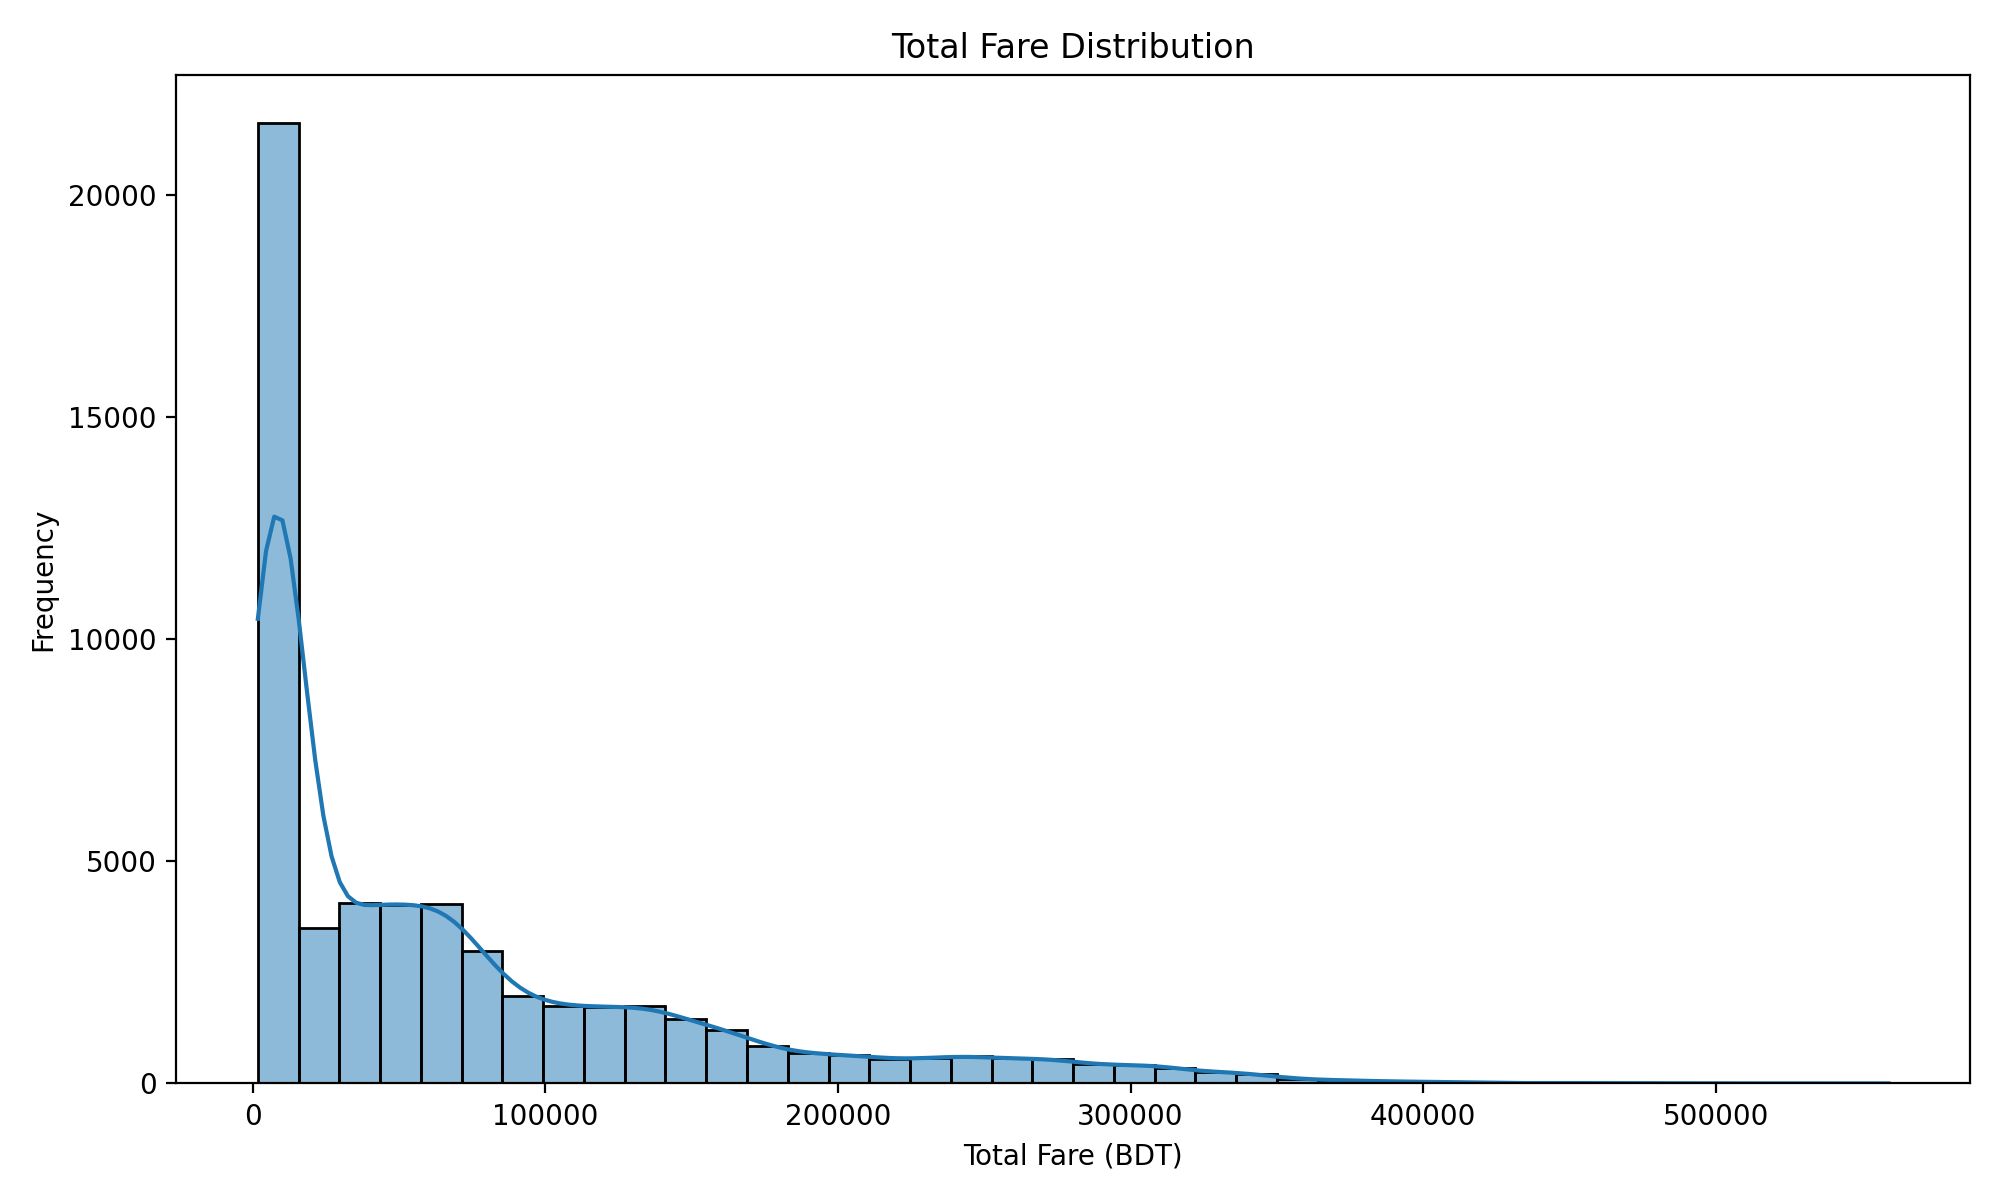

base_fare_distribution.png


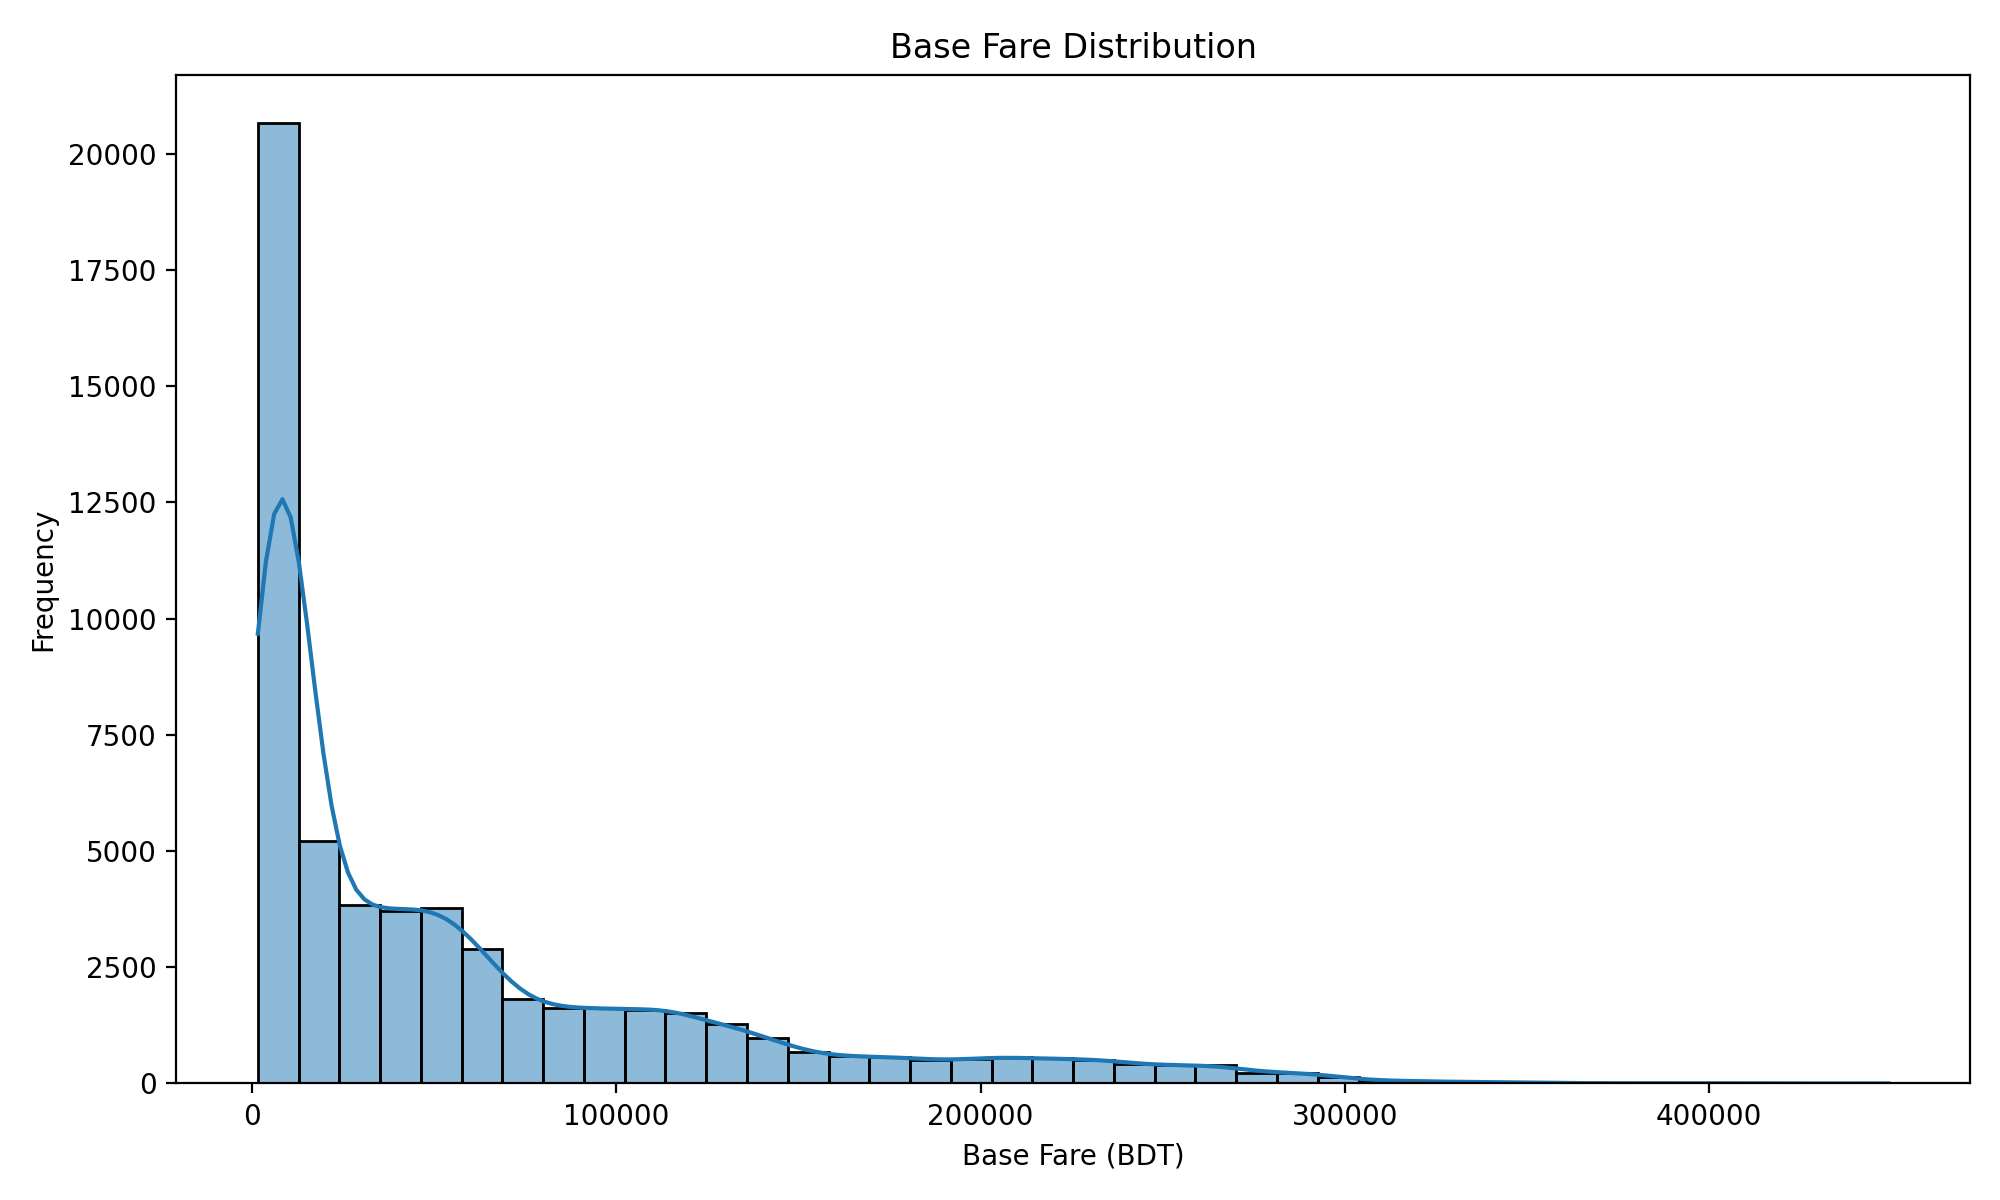

tax_distribution.png


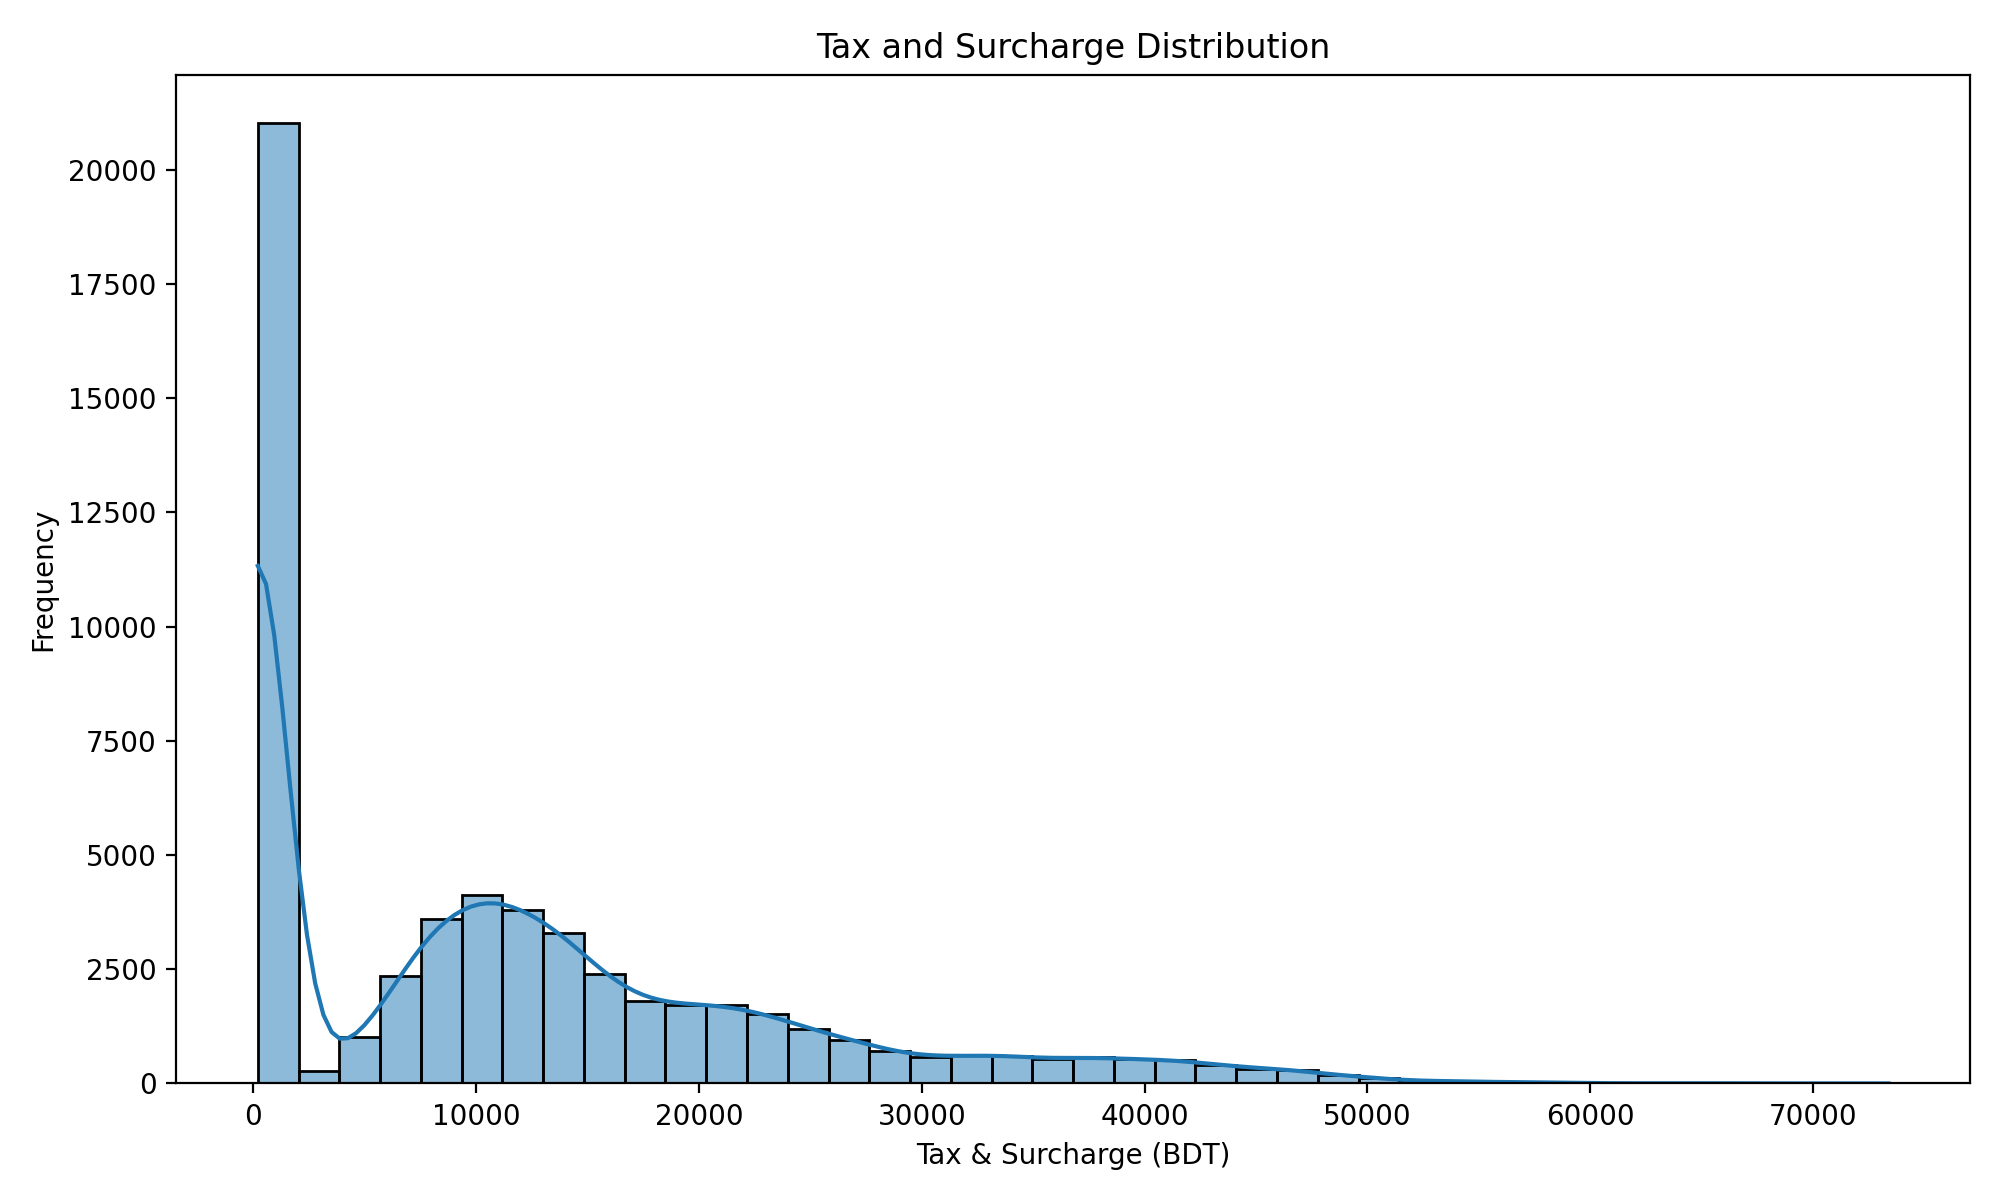

airline_fare_boxplot.png


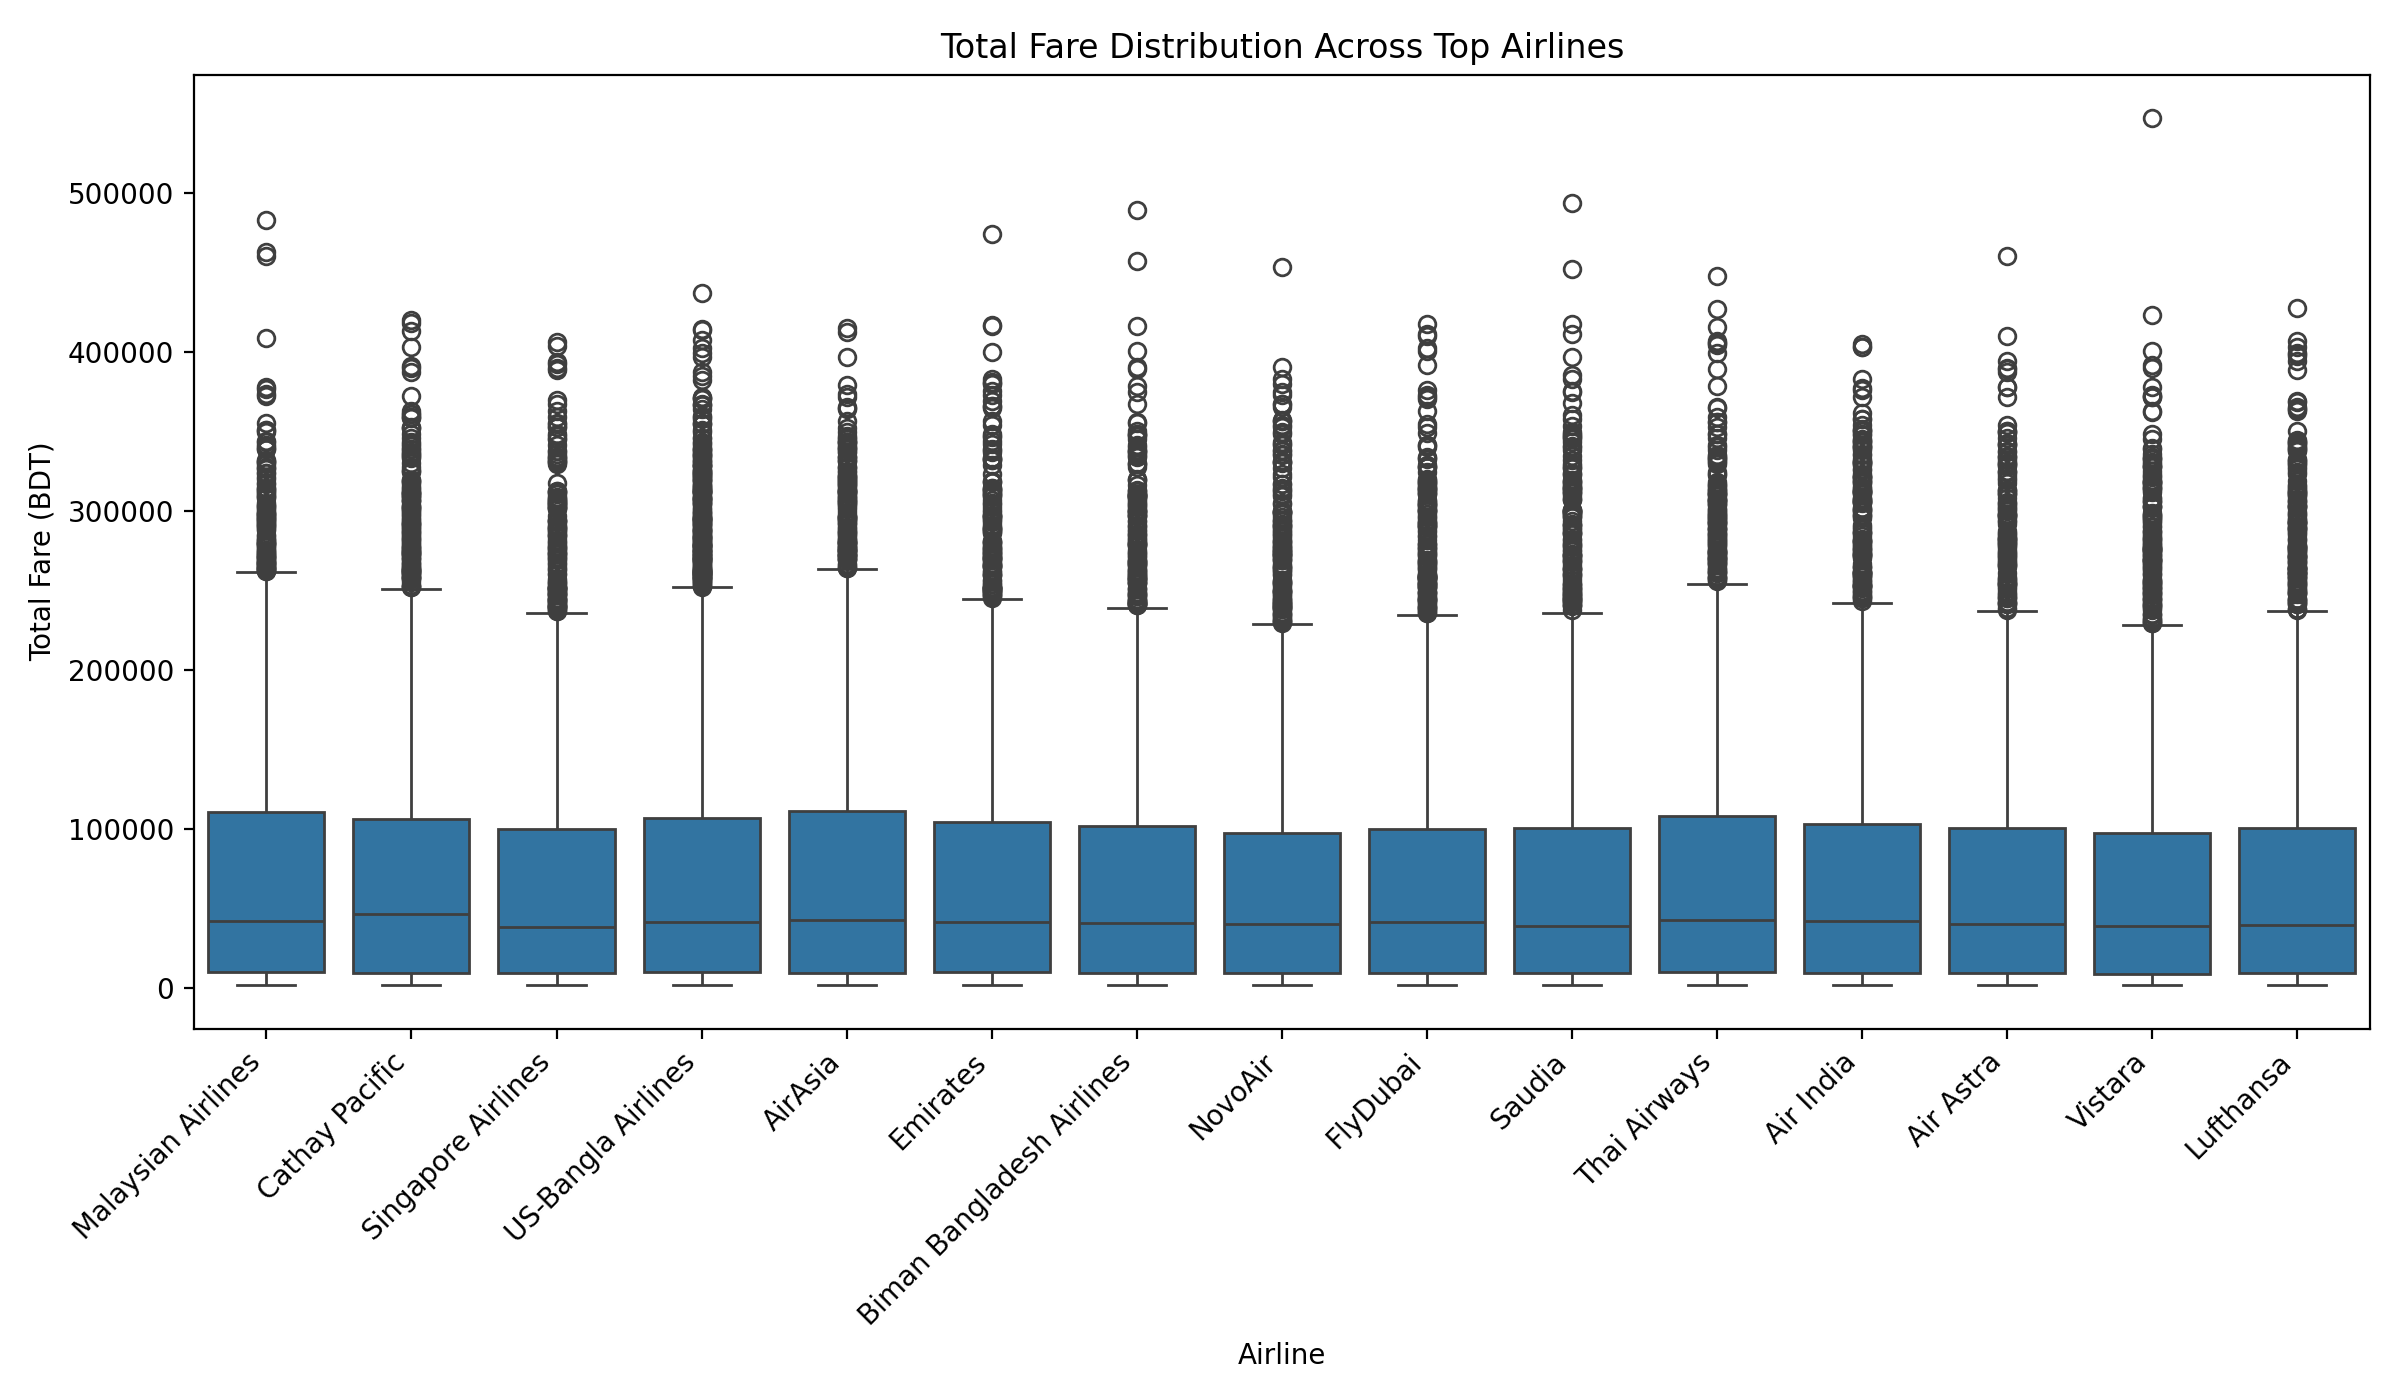

monthly_average_fare.png


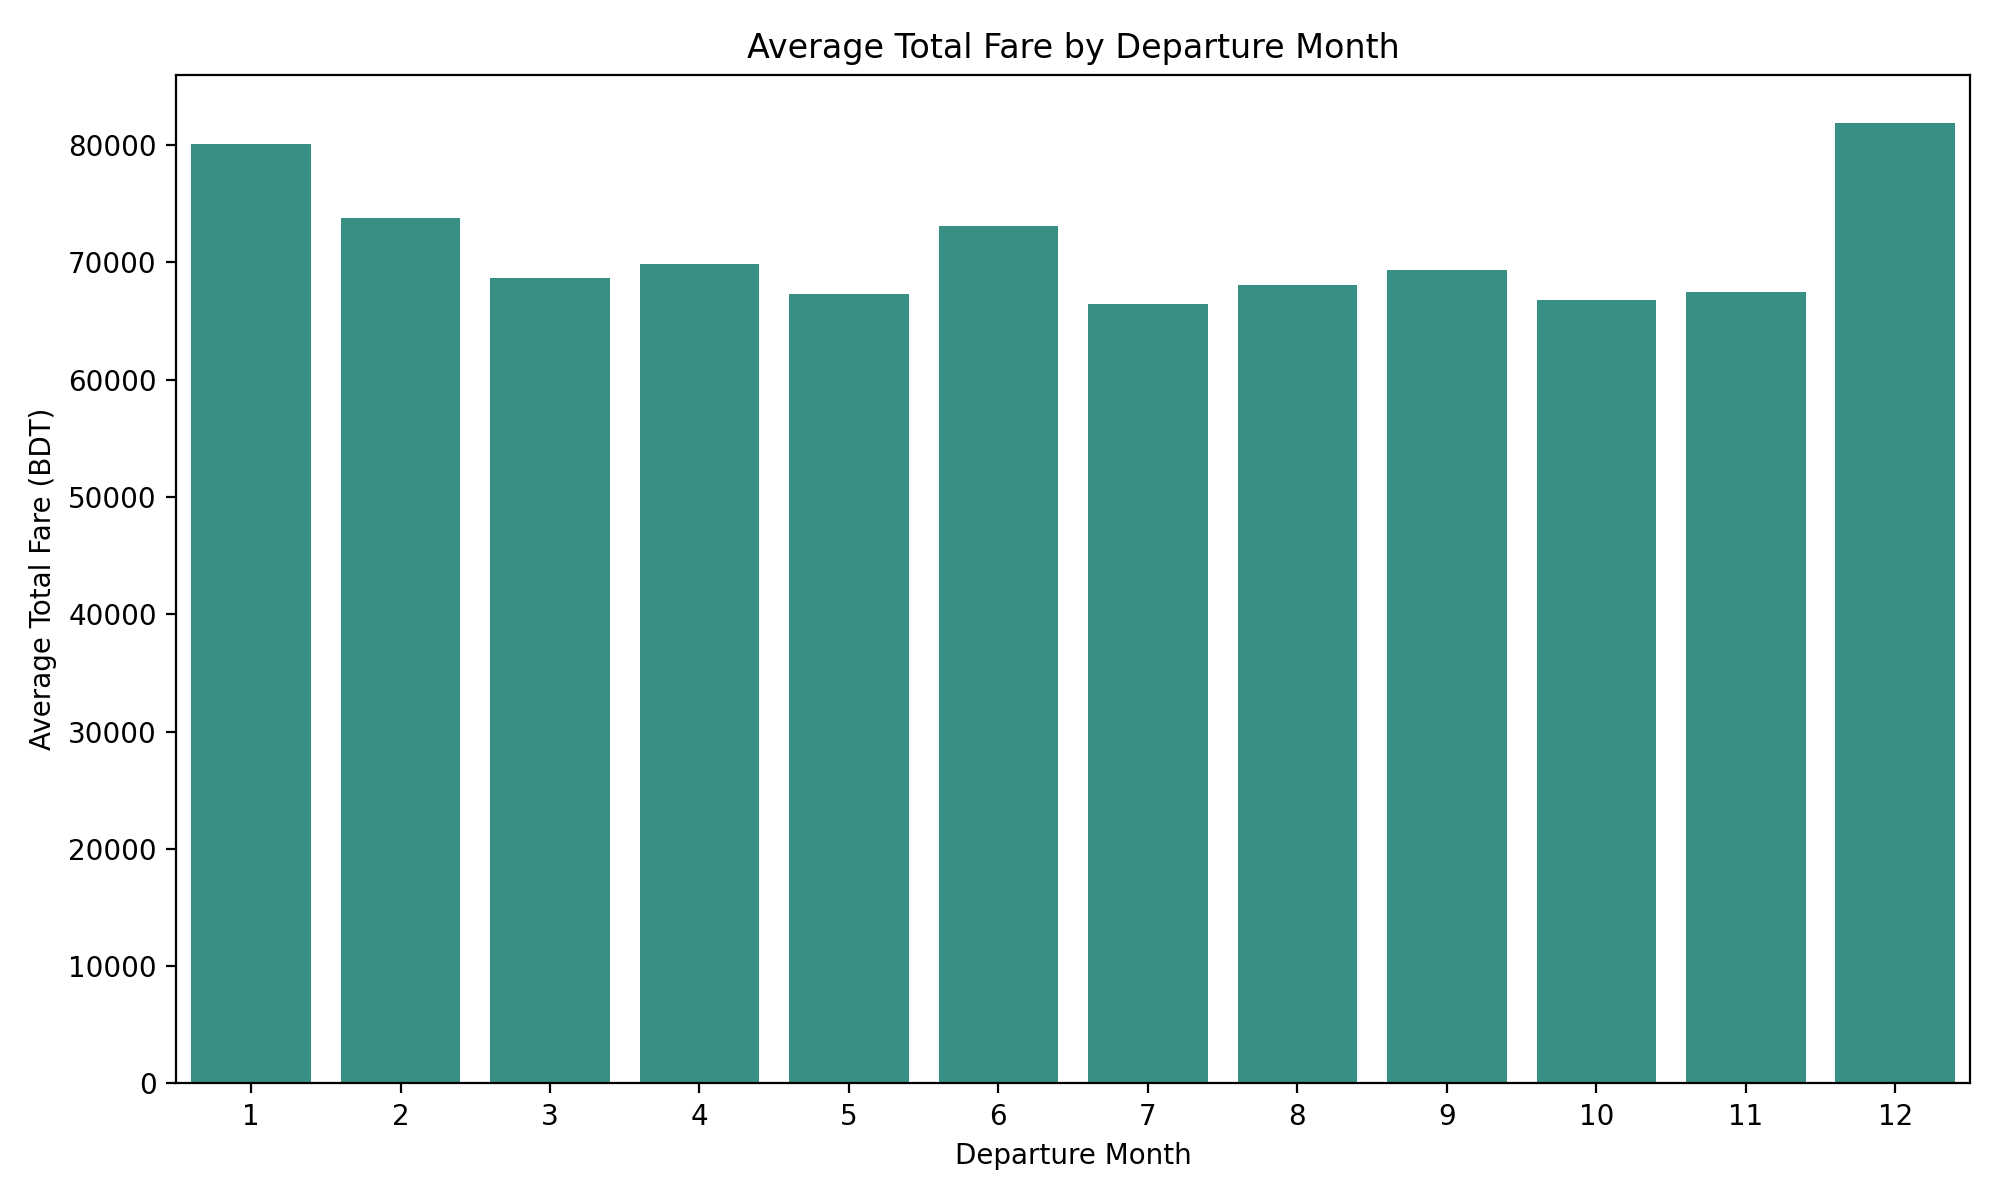

correlation_heatmap.png


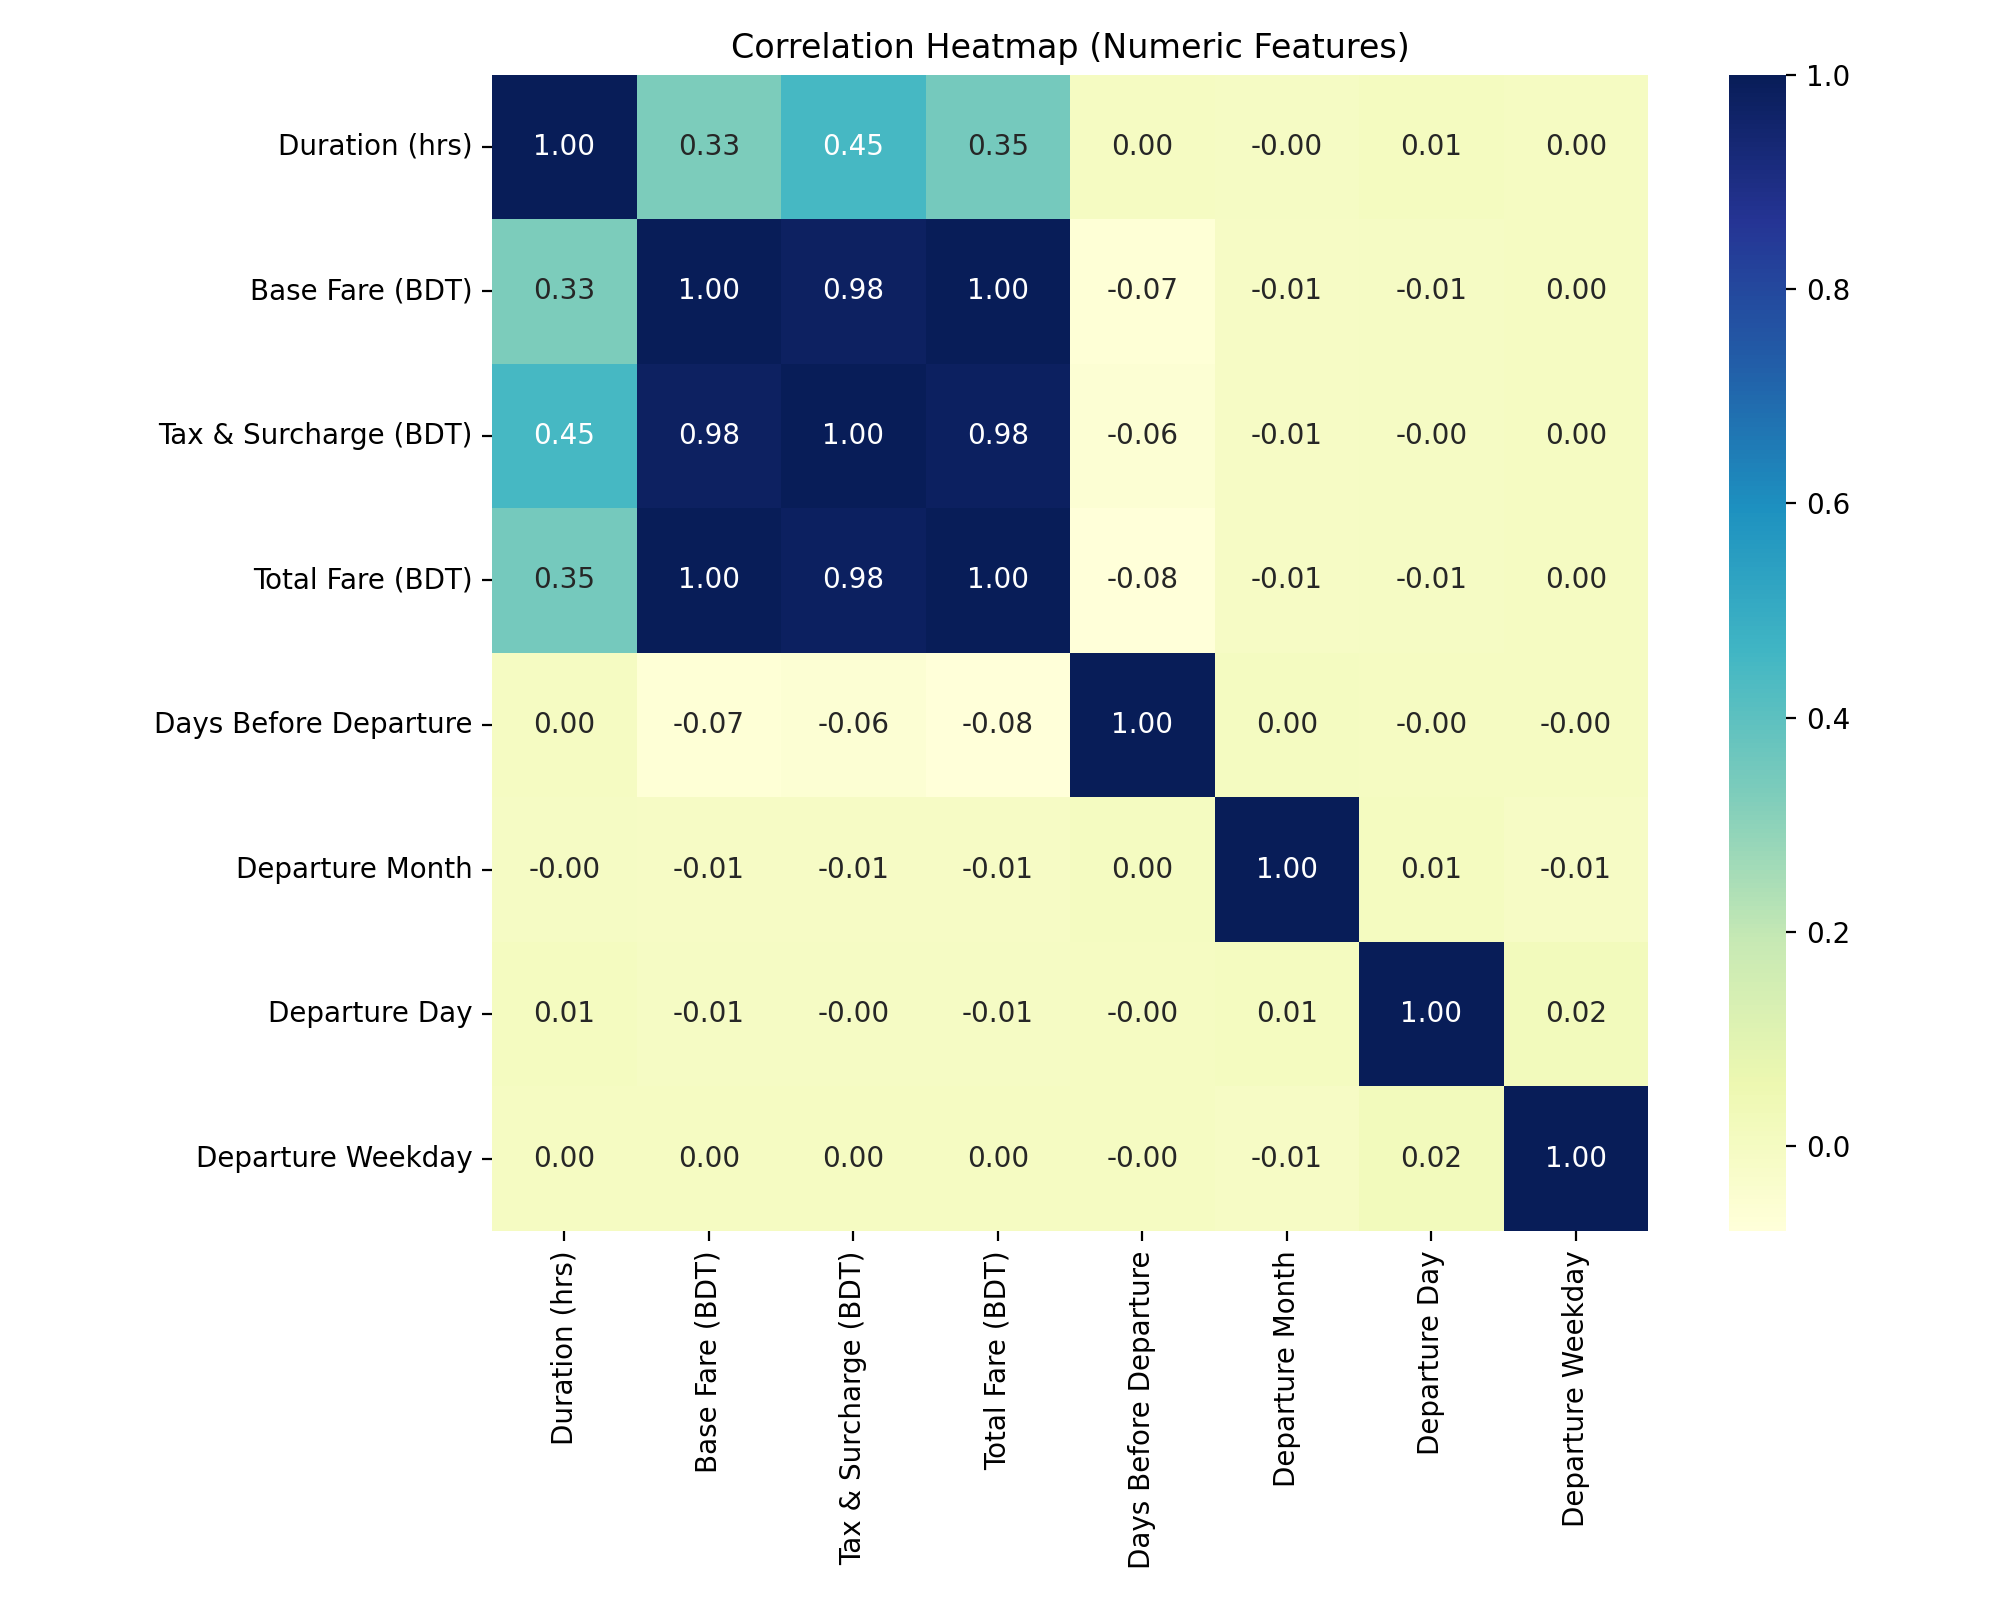

In [ ]:
plot_files = [
    'total_fare_distribution.png',
    'base_fare_distribution.png',
    'tax_distribution.png',
    'airline_fare_boxplot.png',
    'monthly_average_fare.png',
    'correlation_heatmap.png',
]

for file_name in plot_files:
    image_path = Path(outputs.plots_directory) / file_name
    if image_path.exists():
        print(file_name)
        display(Image(filename=str(image_path)))
    else:
        print(f'Missing plot: {file_name}')